## Curse of Dimensionality Code File

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

In [ ]:
random = np.random.default_rng(1)

n_samples = 240
n_repeats = 40
dimensions = np.array([2, 5, 10, 25, 50, 100, 150])

rand_pts_mean_distance = []
train_mse_mean = []
test_mse_mean = []

for d in dimensions:
    mean_distances = []
    train_errs = []
    test_errs = []

    for _ in range(n_repeats):
        X = random.normal(size=(n_samples, d))
        signal = X[:, 0] + 0.5 * np.sin(2 * X[:, 1]) if d > 1 else X[:, 0]
        y = signal + random.normal(scale=1.0, size=n_samples)

        # Mean pairwise distance among sampled random points
        idx = random.choice(n_samples, size=90, replace=False)
        Xi = X[idx]
        dists = np.sqrt(((Xi[:, None, :] - Xi[None, :, :]) ** 2).sum(axis=2))
        triu = np.triu_indices_from(dists, k=1)
        mean_distances.append(np.mean(dists[triu]))

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.4, random_state=int(random.integers(0, 1000000))
        )

        model = make_pipeline(StandardScaler(), Ridge(alpha=1e-3))
        model.fit(X_train, y_train)
        yhat_train = model.predict(X_train)
        yhat_test = model.predict(X_test)

        train_errs.append(mean_squared_error(y_train, yhat_train))
        test_errs.append(mean_squared_error(y_test, yhat_test))

    rand_pts_mean_distance.append(np.mean(mean_distances))
    train_mse_mean.append(np.mean(train_errs))
    test_mse_mean.append(np.mean(test_errs))

rand_pts_mean_distance = np.array(rand_pts_mean_distance)
train_mse_mean = np.array(train_mse_mean)
test_mse_mean = np.array(test_mse_mean)

density_gap = test_mse_mean - train_mse_mean

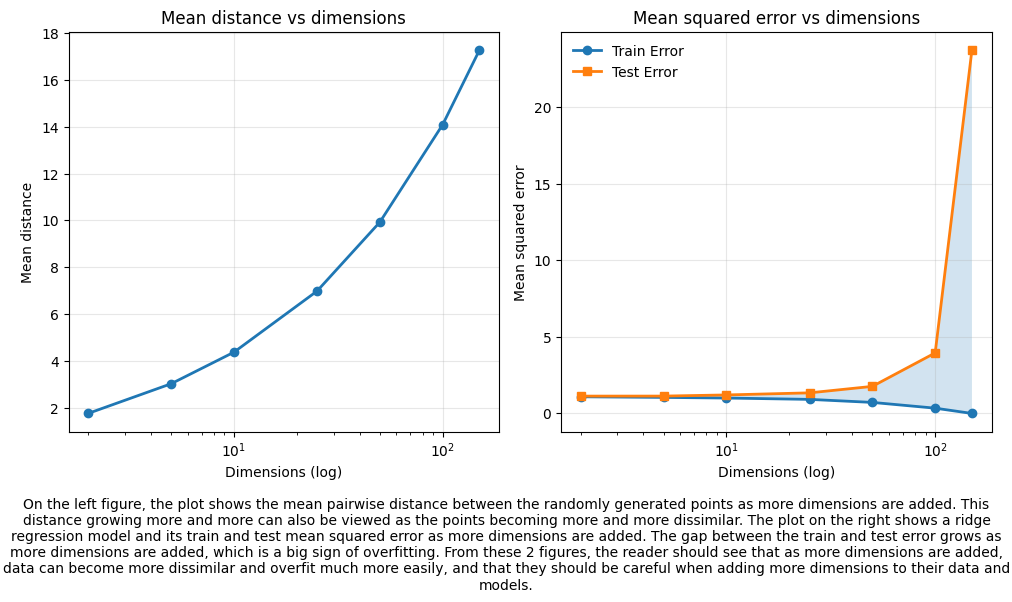

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

plt1, plt2 = ax[0], ax[1]

plt1.plot(dimensions, rand_pts_mean_distance, marker='o', lw=2)
plt1.set_xscale('log')
plt1.set_xlabel('Dimensions (log)')
plt1.set_ylabel('Mean distance')
plt1.set_title('Mean distance vs dimensions')
plt1.grid(alpha=0.3)

plt2.plot(dimensions, train_mse_mean, marker='o', lw=2, label='Train Error')
plt2.plot(dimensions, test_mse_mean, marker='s', lw=2, label='Test Error')
plt2.fill_between(dimensions, train_mse_mean, test_mse_mean, alpha=0.2)
plt2.set_xscale('log')
plt2.set_xlabel('Dimensions (log)')
plt2.set_ylabel('Mean squared error')
plt2.set_title('Mean squared error vs dimensions')
plt2.legend(frameon=False)
plt2.grid(alpha=0.3)

caption = ('On the left figure, the plot shows the mean pairwise distance between the randomly generated points as more dimensions are added. This distance growing more and more can also be viewed as the points becoming more and more dissimilar. The plot on the right shows a ridge regression model and its train and test mean squared error as more dimensions are added. The gap between the train and test error grows as more dimensions are added, which is a big sign of overfitting. From these 2 figures, the reader should see that as more dimensions are added, data can become more dissimilar and overfit much more easily, and that they should be careful when adding more dimensions to their data and models.')
fig.text(0.5, -0.1, caption, ha='center', va='center', wrap=True)
fig.tight_layout()
fig.savefig('AlttiK_CoD.png', bbox_inches='tight')
plt.show()